# CS614 Final Project — AI Industrial Quality Inspector (NEU Surface Defects)
## Roy Phelps

## Dataset

This project uses the **NEU Surface Defect Database**, a publicly available dataset of hot-rolled steel surface defects.

Classes:
- crazing
- inclusion
- patches
- pitted_surface
- rolled-in_scale
- scratches

Dataset source:  
https://www.kaggle.com/datasets/bobweng/neu-surface-defect-dataset

## Outline
1. Problem and Pitch
2. Dataset and Setup
3. Exploratory Checks (Samples and Balance)
4. Model Setup (ResNet18 fine-tuning)
5. Training
6. Evaluation (Loss, Accuracy, and Confusion Matrix)
7. Demo and Predictions
8. Reproducibility and How to Run

# 1. Problem and Pitch


## Pitch (Problem → Solution)
Manual surface inspection in manufacturing is slow and inconsistent. This project demonstrates a proof-of-concept computer vision model that classifies surface defect types and can later be extended with visual explanations (Grad-CAM) for trust.

## Technical Approach

This project follows **Option 2 from the course guidelines**: fine-tuning a pretrained deep learning model on a new dataset.

We use a pretrained **ResNet18 convolutional neural network** (originally trained on the ImageNet dataset) and adapt it to classify six surface defect types from the NEU surface defect dataset.

Transfer learning allows the model to leverage previously learned visual features while adapting the final classification layer to the new defect categories.

## Market Gap
- Manual inspection is slow and subjective
- Existing inspection systems can be expensive or hard to interpret.
- A low-cost AI proof-of-concept could improve consistency and speed.

# 2. Dataset and Setup

## Import Statements

In [17]:
# Import
# NOTE: Some imports like the confusion matrix will be used later during evaluation.
import os
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
from torchvision import datasets, transforms

## Dataset & Folder Structure
Dataset: NEU Surface Defects (Kaggle version)

Expected structure:
- data/raw/neu_surface_defects/NEU-DET/train/images/<class_name>/
- data/raw/neu_surface_defects/NEU-DET/validation/images/<class_name>/

We load data using torchvision `ImageFolder`, which requires one folder per class.

In [2]:
# Setting seeds to reproduce fixing random seeds helps
# to make results consistent across runs.

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> project root

DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "neu_surface_defects" / "NEU-DET"

TRAIN_DIR = DATASET_ROOT / "train" / "images"
VAL_DIR   = DATASET_ROOT / "validation" / "images"

# Check: confirm dataset paths exist before attempting to load images. 
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_ROOT:", DATASET_ROOT)
print("TRAIN_DIR exists?:", TRAIN_DIR.exists())
print("VAL_DIR exists?:", VAL_DIR.exists())

PROJECT_ROOT: /Users/royphelps/Library/CloudStorage/OneDrive-DrexelUniversity/CS-614-900/Assignments/Final Project/CS614-AI-Industrial-Quality-Inspector
DATASET_ROOT: /Users/royphelps/Library/CloudStorage/OneDrive-DrexelUniversity/CS-614-900/Assignments/Final Project/CS614-AI-Industrial-Quality-Inspector/data/raw/neu_surface_defects/NEU-DET
TRAIN_DIR exists?: True
VAL_DIR exists?: True


## Loading the Dataset with ImageFolder

PyTorch's `ImageFolder` class automatically assigns numeric labels to images based on their folder names. This simplifies dataset loading for classification tasks where images are organized by class.

In [3]:
# Basic transforms for exploration to resize + tensor conversion.
# For pretrained ResNet fine tuning, we will later add ImageNet normalization and augmentations.

basic_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(root=str(TRAIN_DIR), transform=basic_tfms)
val_ds   = datasets.ImageFolder(root=str(VAL_DIR), transform=basic_tfms)

print("Train images:", len(train_ds))
print("Val images:", len(val_ds))
print("Num classes:", len(train_ds.classes))
print("Classes:", train_ds.classes)
print("Same class mapping?", train_ds.class_to_idx == val_ds.class_to_idx)

Train images: 1440
Val images: 360
Num classes: 6
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Same class mapping? True


# 3. Exploratory Checks (Samples and Balance)

## Visual Inspection of Samples

Before training any model, it is useful to visually inspect a few images to confirm that:

- Images load correctly
- Labels match the expected defect classes
- Defects appear visually distinguishable

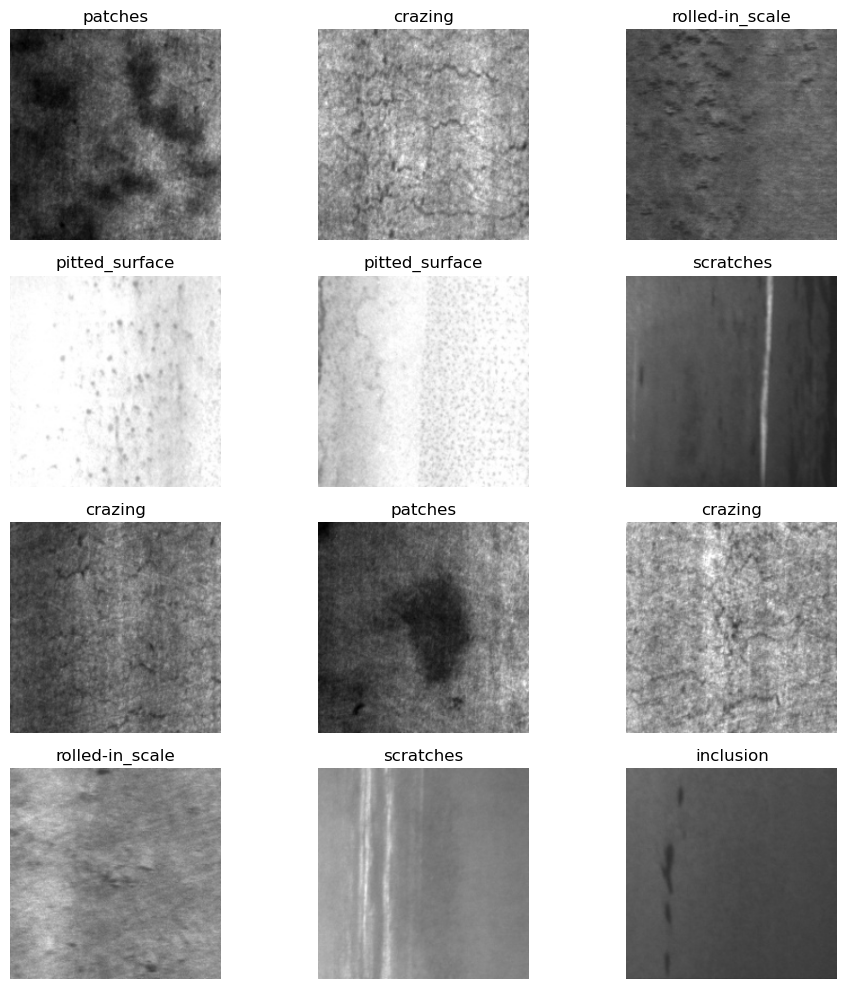

In [4]:


def show_samples(ds, n=12, seed=42):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(ds), size=n, replace=False)

    cols = 3
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(10, 10))

    for i, idx in enumerate(idxs, start=1):
        x, y = ds[idx]  # Tensor CHW, label index
        img = x.permute(1, 2, 0).numpy()  # CHW -> HWC
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(ds.classes[y])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train_ds, n=12)

## Class Distribution Analysis

Balanced datasets are important when training classification models.  
If one class dominates the dataset, the model may become biased toward predicting that class.

The NEU dataset is well balanced, which simplifies training and evaluation.

Train counts:
         crazing: 240
       inclusion: 240
         patches: 240
  pitted_surface: 240
  rolled-in_scale: 240
       scratches: 240

Validation counts:
         crazing: 60
       inclusion: 60
         patches: 60
  pitted_surface: 60
  rolled-in_scale: 60
       scratches: 60


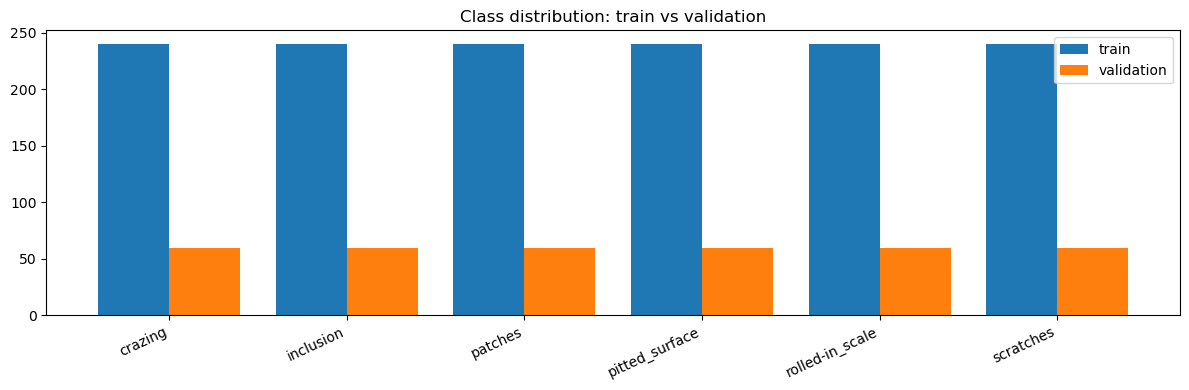

In [5]:
# ImageFolder automatically maps folder names to class labels

def class_counts(imagefolder_ds):
    targets = [y for _, y in imagefolder_ds.samples]
    counts = np.bincount(targets, minlength=len(imagefolder_ds.classes))
    return counts

train_counts = class_counts(train_ds)
val_counts   = class_counts(val_ds)

print("Train counts:")
for cls, cnt in zip(train_ds.classes, train_counts):
    print(f"  {cls:>14}: {cnt}")

print("\nValidation counts:")
for cls, cnt in zip(val_ds.classes, val_counts):
    print(f"  {cls:>14}: {cnt}")

# Plot side-by-side bars 
x = np.arange(len(train_ds.classes))
width = 0.4

plt.figure(figsize=(12,4))
plt.bar(x - width/2, train_counts, width, label="train")
plt.bar(x + width/2, val_counts, width, label="validation")
plt.xticks(x, train_ds.classes, rotation=25, ha="right")
plt.title("Class distribution: train vs validation")
plt.legend()
plt.tight_layout()

# Save the chart in the outputs folder
FIG_PATH = PROJECT_ROOT / "outputs" / "figures" / "balance.png"
plt.savefig(FIG_PATH, dpi=300, bbox_inches="tight")

plt.show()

# Model Development

The next stage of the project is to fine-tune a pretrained convolutional neural network (ResNet18) on the NEU surface defect dataset.

Steps:
1. Create DataLoaders for batching images
2. Load a pretrained ResNet18 model
3. Replace the final classification layer for 6 defect classes
4. Train the model on the training set
5. Evaluate performance on the validation set

# 4. Model Setup (ResNet18 fine-tuning)

## Improve image preprocessing

In [6]:
# Transforms for training a pretrained ResNet model
train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Reload datasets with new transforms

In [7]:
train_ds = datasets.ImageFolder(root=str(TRAIN_DIR), transform=train_tfms)
val_ds   = datasets.ImageFolder(root=str(VAL_DIR), transform=val_tfms)

## Creating DataLoaders

DataLoaders allow PyTorch to load images in batches during training, which improves training efficiency and enables GPU acceleration if available.

In [8]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 45
Validation batches: 12


## Loading a Pretrained ResNet18 Model

Instead of training a model from scratch, we use **transfer learning** by fine-tuning a pretrained ResNet18 model that was originally trained on the ImageNet dataset.

The final classification layer will be replaced to match our six defect categories.

In [9]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

weights = ResNet18_Weights.IMAGENET1K_V1
model = resnet18(weights=weights)

num_classes = len(train_ds.classes)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)

print(model.fc)

Device: cpu
Linear(in_features=512, out_features=6, bias=True)


## Loss and optimizer

In [10]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4)

# 5.  Training

## Training and evaluation loops

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

## Train for new epochs

In [12]:
EPOCHS = 8

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    va_loss, va_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}, Train Acc: {tr_acc:.3f} | "
          f"Val Loss: {va_loss:.4f}, Val Acc: {va_acc:.3f}")

Epoch 01/8 | Train Loss: 0.2246, Train Acc: 0.928 | Val Loss: 0.1687, Val Acc: 0.942
Epoch 02/8 | Train Loss: 0.0674, Train Acc: 0.978 | Val Loss: 0.1689, Val Acc: 0.969
Epoch 03/8 | Train Loss: 0.0359, Train Acc: 0.990 | Val Loss: 0.0051, Val Acc: 1.000
Epoch 04/8 | Train Loss: 0.0391, Train Acc: 0.984 | Val Loss: 0.0103, Val Acc: 1.000
Epoch 05/8 | Train Loss: 0.0205, Train Acc: 0.995 | Val Loss: 0.0017, Val Acc: 1.000
Epoch 06/8 | Train Loss: 0.0155, Train Acc: 0.995 | Val Loss: 0.0030, Val Acc: 1.000
Epoch 07/8 | Train Loss: 0.0268, Train Acc: 0.991 | Val Loss: 0.0503, Val Acc: 0.972
Epoch 08/8 | Train Loss: 0.0201, Train Acc: 0.994 | Val Loss: 0.0017, Val Acc: 1.000


# 6.  Evaluation (Loss, Accuracy, and Confusion Matrix)

### Training Result Summary

After 8 epochs of fine-tuning a pretrained ResNet18 model, the classifier achieved:
- Training accuracy: ~99.5%
- Validation accuracy: Reached **100%** on 5 out of 8 epochs

These results demonstrate a strong proof-of-concept for automated defect classification on the NEU surface defect dataset.

## Plot the training curves and save them to the ouput folder

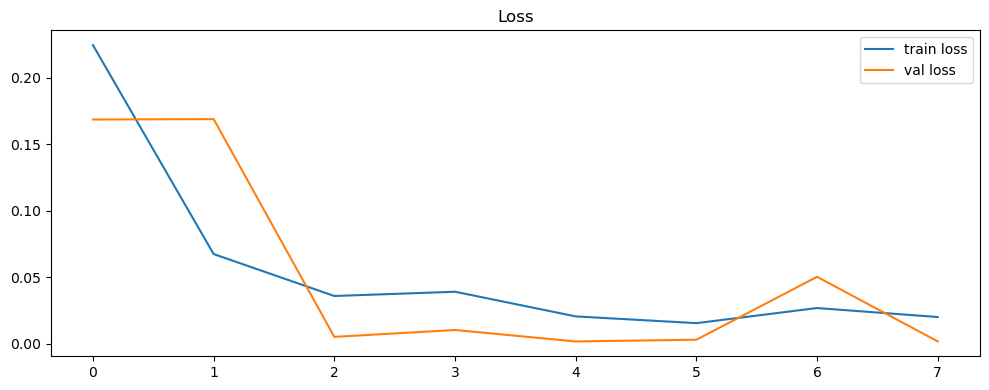

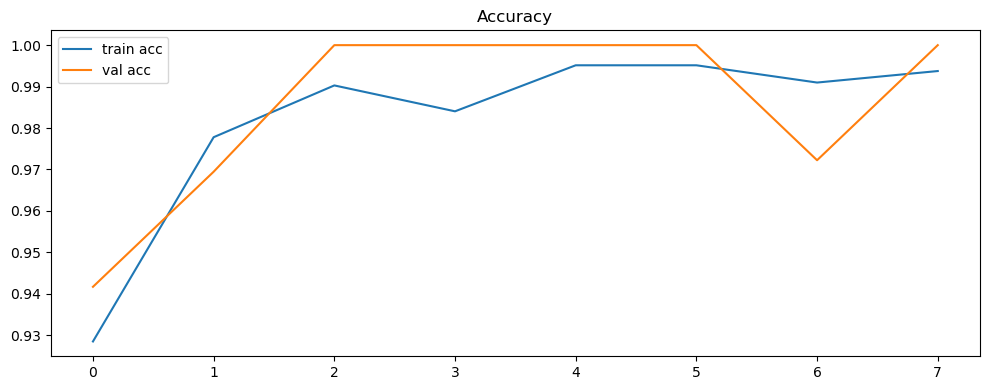

In [13]:
import matplotlib.pyplot as plt

FIG_PATH = PROJECT_ROOT / "outputs" / "figures" / "loss.png"
plt.figure(figsize=(10,4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.title("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

FIG_PATH = PROJECT_ROOT / "outputs" / "figures" / "accuracy.png"
plt.figure(figsize=(10,4))
plt.plot(history["train_acc"], label="train acc")
plt.plot(history["val_acc"], label="val acc")
plt.title("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

## Confusion Matrix

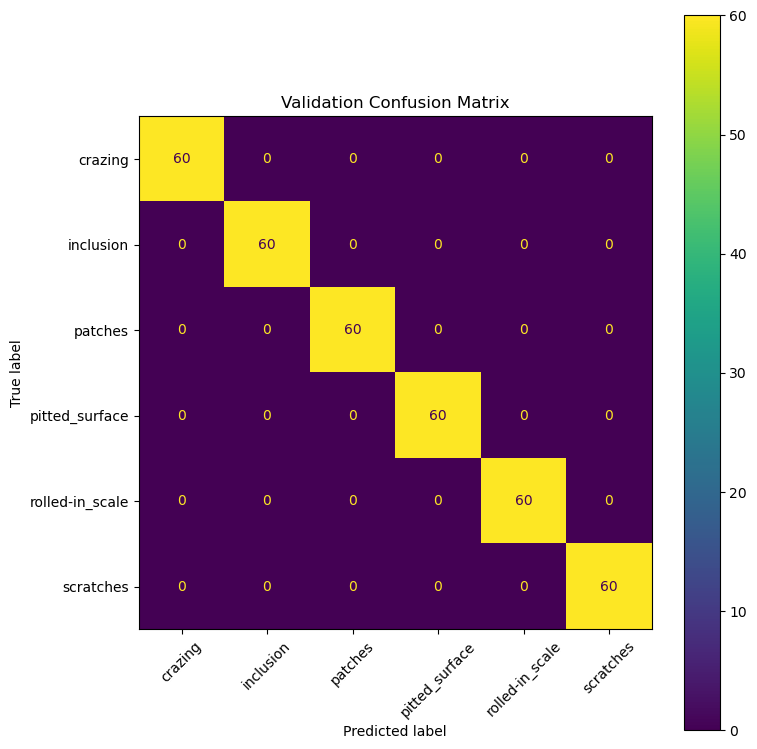

In [14]:
@torch.no_grad()
def get_preds_labels(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)

preds, labels = get_preds_labels(model, val_loader, device)

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_ds.classes)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, xticks_rotation=45, values_format='d')
plt.title("Validation Confusion Matrix")
plt.tight_layout()

# Save the figure to the ouput folder
CM_PATH = PROJECT_ROOT / "outputs" / "figures" / "confusion_matrix.png"
plt.savefig(CM_PATH, dpi=300, bbox_inches="tight")

plt.show()

## Model save so it is reproducible 

In [15]:
MODEL_PATH = PROJECT_ROOT / "outputs" / "models" / "resnet18_neu_defects.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": train_ds.class_to_idx
}, MODEL_PATH)

print("Saved model to:", MODEL_PATH)

Saved model to: /Users/royphelps/Library/CloudStorage/OneDrive-DrexelUniversity/CS-614-900/Assignments/Final Project/CS614-AI-Industrial-Quality-Inspector/outputs/models/resnet18_neu_defects.pt


# 7. Demo and Predictions

## Show predictions on a few validation images

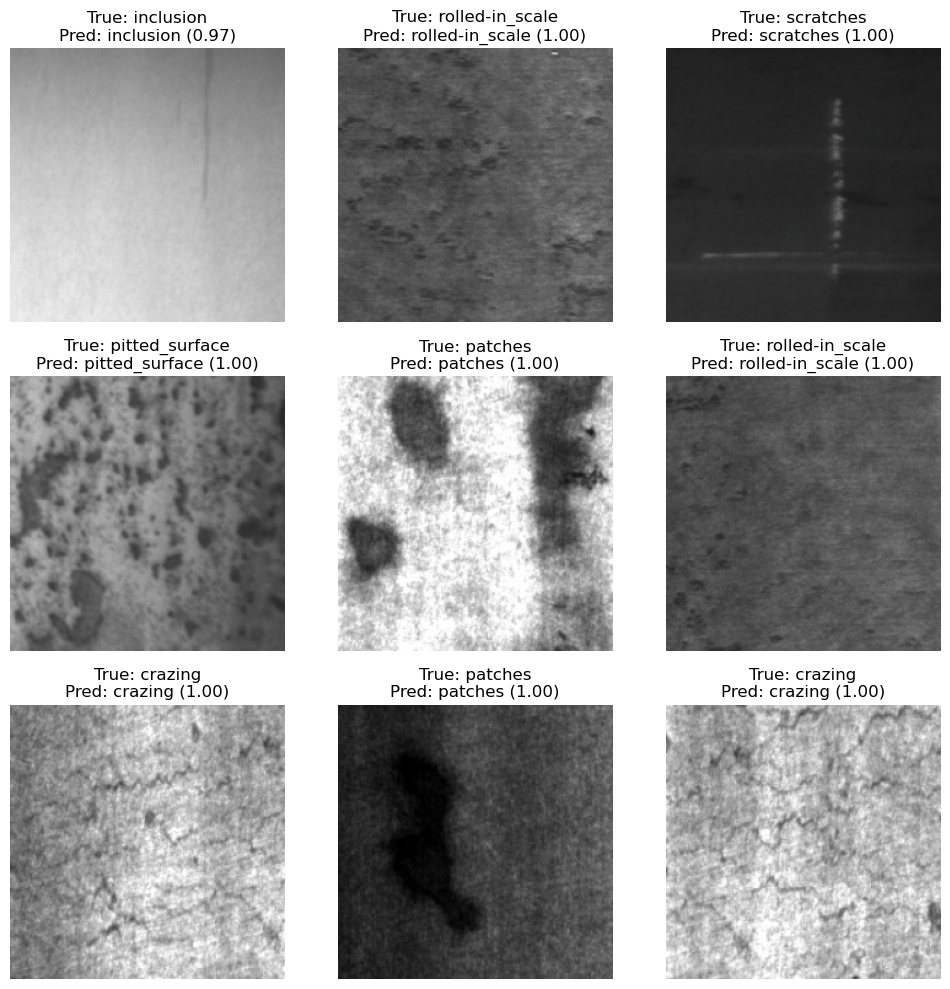

In [16]:
import torch.nn.functional as F

@torch.no_grad()
def demo_predictions(model, ds, n=9, seed=42):
    model.eval()
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(ds), size=n, replace=False)

    cols = 3
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(10, 10))

    for i, idx in enumerate(idxs, start=1):
        x, y = ds[idx]
        x_in = x.unsqueeze(0).to(device)

        logits = model(x_in)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        pred = int(np.argmax(probs))
        conf = float(np.max(probs))

        # de-normalize for display (because we normalized for ResNet)
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img = x.permute(1,2,0).cpu().numpy()
        img = (img * std) + mean
        img = np.clip(img, 0, 1)

        title = f"True: {ds.classes[y]}\nPred: {ds.classes[pred]} ({conf:.2f})"

        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()

    # Save the images to the output folder
    DEMO_PATH = PROJECT_ROOT / "outputs" / "figures" / "demo_predictions.png"
    plt.savefig(DEMO_PATH, dpi=300, bbox_inches="tight")
    
    plt.show()

demo_predictions(model, val_ds, n=9)

# 8. Reproducibility

## Reproducibility / How to Run

1. Install dependencies from `requirements.txt`
2. Place the NEU dataset in the expected `data/raw/...` directory
3. Run the notebook from top to bottom
4. The trained model will be saved to `outputs/models/`
5. Figures will be saved to `outputs/figures/`